# Ranking Policy Top-K Applicability Analysis

For each molecule in the SA score benchmark (7 bins, 100 molecules each),
we ask the ranking policy for its top 50 rules and check whether each rule
actually applies (produces valid products). This tells us how many of the
policy's recommendations are actionable, stratified by molecular complexity.

#### Summary of the results

**1. Rule applicability is NOT the bottleneck for hard molecules.** The mean number of applicable rules drops only moderately with SA score: 15.5 (easy) → 10.4 (dip at 4.5–5.5) → 12.1 (hardest bin). The rules apply; they just don't lead to solvable routes.

**2. Probability mass waste degrades with complexity.** On easy molecules, 77.5% of the ranking policy's probability lands on applicable rules. On hard molecules, nearly half (~48%) the confidence is wasted on inapplicable rules. 

**3. 26 molecules across all bins have zero applicable rules in top-50.** They cannot be solved with default setup (cf. pct_with_any in 4.)

TO DO: Compute network's top-1 confidence to show how concentrated the policy is.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

from chython import smiles as parse_smiles
from synplan.chem.precursor import Precursor
from synplan.chem.reaction import apply_reaction_rule
from synplan.mcts.expansion import PolicyNetworkFunction
from synplan.utils.config import PolicyNetworkConfig
from synplan.utils.loading import load_reaction_rules

## 1. Load resources

In [2]:
from synplan.utils.loading import download_preset

paths = download_preset("synplanner-article", save_to=Path("synplan_data"))

RANKING_POLICY = paths["ranking_policy"]
RULES_PATH     = paths["reaction_rules"]
BENCH_DIR      = Path("../scripts/benchmark/sascore")

TOP_RULES = 50

# SA score bins
BINS = ["1.5_2.5", "2.5_3.5", "3.5_4.5", "4.5_5.5", "5.5_6.5", "6.5_7.5", "7.5_8.5"]
BIN_LABELS = [b.replace("_", "\u2013") for b in BINS]

Couldn't access the Hub to check for update but local file already exists. Defaulting to existing file. (error: [Errno 101] Network is unreachable)
Couldn't access the Hub to check for update but local file already exists. Defaulting to existing file. (error: [Errno 101] Network is unreachable)


In [3]:
# Load ranking policy
ranking_config = PolicyNetworkConfig(
    weights_path=str(RANKING_POLICY),
    policy_type="ranking",
    top_rules=TOP_RULES,
    rule_prob_threshold=0.0,
)
ranking_fn = PolicyNetworkFunction(ranking_config)

# Load reaction rules
reaction_rules = load_reaction_rules(str(RULES_PATH))
print(f"Ranking policy loaded. Reaction rules: {len(reaction_rules)}")

Lightning automatically upgraded your loaded checkpoint from v1.9.5 to v2.6.0. To apply the upgrade to your files permanently, run `python -m pytorch_lightning.utilities.upgrade_checkpoint synplan_data/policy/supervised_gcn/v1/v1/ranking_policy.ckpt`


Ranking policy loaded. Reaction rules: 24094


## 2. Evaluate top-K applicability per molecule

In [4]:
def check_rule_applicability(smiles: str, ranking_fn, reaction_rules, top_k: int = TOP_RULES):
    """For a molecule, get the top-k ranked rules and check which ones apply.
    
    Returns a list of dicts with rank, rule_id, probability, and whether the rule
    produced at least one valid set of products.
    """
    mol = parse_smiles(smiles)
    if mol is None:
        return None
    try:
        mol.canonicalize()
        precursor = Precursor(mol)
    except Exception:
        return None

    results = []
    for rank, (prob, rule, rule_id) in enumerate(
        ranking_fn.predict_reaction_rules(precursor, reaction_rules)
    ):
        # Check if rule actually produces valid products
        applicable = False
        n_product_sets = 0
        try:
            for products in apply_reaction_rule(precursor.molecule, rule):
                if products:
                    applicable = True
                    n_product_sets += 1
        except Exception:
            pass

        results.append({
            "rank": rank + 1,
            "rule_id": rule_id,
            "prob": prob,
            "applicable": applicable,
            "n_product_sets": n_product_sets,
        })
    return results

In [5]:
rows = []

for bin_name in BINS:
    smi_file = BENCH_DIR / f"targets_with_sascore_{bin_name}.smi"
    molecules = smi_file.read_text().strip().splitlines()
    print(f"\nBin {bin_name}: {len(molecules)} molecules")

    for mol_idx, smi in enumerate(tqdm(molecules, desc=bin_name)):
        smi = smi.strip().split()[0]  # handle possible whitespace / extra columns
        rule_results = check_rule_applicability(smi, ranking_fn, reaction_rules, TOP_RULES)
        if rule_results is None:
            continue
        for r in rule_results:
            rows.append({
                "bin": bin_name,
                "mol_idx": mol_idx,
                "smiles": smi,
                **r,
            })
            
df = pd.DataFrame(rows)

print(f"\nTotal rows: {len(df)} ({len(df) // TOP_RULES} molecules x {TOP_RULES} rules)")
df.head(10)


Bin 1.5_2.5: 100 molecules


1.5_2.5:   0%|          | 0/100 [00:00<?, ?it/s]


Bin 2.5_3.5: 100 molecules


2.5_3.5:   0%|          | 0/100 [00:00<?, ?it/s]


Bin 3.5_4.5: 100 molecules


...

6.5_7.5:   0%|          | 0/100 [00:00<?, ?it/s]


Bin 7.5_8.5: 100 molecules


7.5_8.5:   0%|          | 0/100 [00:00<?, ?it/s]


Total rows: 35000 (700 molecules x 50 rules)


,bin,mol_idx,smiles,rank,rule_id,prob,applicable,n_product_sets
0,1.5_2.5,0,O=C(O)COc1cc(OCC(=O)O)c2c3c(c(=O)oc2c1)CCC3,1,1,0.520883,True,2
1,1.5_2.5,0,O=C(O)COc1cc(OCC(=O)O)c2c3c(c(=O)oc2c1)CCC3,2,8,0.470041,True,2
2,1.5_2.5,0,O=C(O)COc1cc(OCC(=O)O)c2c3c(c(=O)oc2c1)CCC3,3,231,0.002253,True,2
3,1.5_2.5,0,O=C(O)COc1cc(OCC(=O)O)c2c3c(c(=O)oc2c1)CCC3,4,40,0.001965,True,2
4,1.5_2.5,0,O=C(O)COc1cc(OCC(=O)O)c2c3c(c(=O)oc2c1)CCC3,5,595,0.001544,True,2
5,1.5_2.5,0,O=C(O)COc1cc(OCC(=O)O)c2c3c(c(=O)oc2c1)CCC3,6,1284,0.001480,True,2
6,1.5_2.5,0,O=C(O)COc1cc(OCC(=O)O)c2c3c(c(=O)oc2c1)CCC3,7,895,0.001251,True,2
7,1.5_2.5,0,O=C(O)COc1cc(OCC(=O)O)c2c3c(c(=O)oc2c1)CCC3,8,17071,0.000380,True,2
8,1.5_2.5,0,O=C(O)COc1cc(OCC(=O)O)c2c3c(c(=O)oc2c1)CCC3,9,869,0.000091,True,2
9,1.5_2.5,0,O=C(O)COc1cc(OCC(=O)O)c2c3c(c(=O)oc2c1)CCC3,10,1778,0.000026,True,2


## 3. Per-molecule summary

In [6]:
# Aggregate per molecule: how many of the top-K rules are applicable?
mol_summary = (
    df.groupby(["bin", "mol_idx", "smiles"])
    .agg(
        n_applicable=("applicable", "sum"),
        total_prob_applicable=("prob", lambda x: x[df.loc[x.index, "applicable"]].sum()),
        first_applicable_rank=("rank", lambda x: x[df.loc[x.index, "applicable"]].min()),
    )
    .reset_index()
)
mol_summary["frac_applicable"] = mol_summary["n_applicable"] / TOP_RULES
mol_summary["has_any_applicable"] = mol_summary["n_applicable"] > 0
mol_summary.head()

,bin,mol_idx,smiles,n_applicable,total_prob_applicable,first_applicable_rank,frac_applicable,has_any_applicable
0,1.5_2.5,0,O=C(O)COc1cc(OCC(=O)O)c2c3c(c(=O)oc2c1)CCC3,27,0.999986,1.0,0.54,True
1,1.5_2.5,1,COc1cc(C)c(OC)c(CC=C(C)CCC=C(C)C)c1,4,0.362982,1.0,0.08,True
2,1.5_2.5,2,N#CCCN(C(=O)CN1CCN(S(=O)(=O)c2ccc(Cl)s2)CC1)c1...,16,0.989663,1.0,0.32,True
3,1.5_2.5,3,NC1=C2NN(c3ccccc3)C=C2NC(Cc2ccccc2O)=N1,14,0.510638,2.0,0.28,True
4,1.5_2.5,4,COc1ccc(NC2=C3NC=CN3C=C(c3ccc(OC)c(C(N)=O)c3)N...,18,0.210174,2.0,0.36,True


## 4. Applicability by SA score bin

In [7]:
bin_summary = (
    mol_summary.groupby("bin")
    .agg(
        n_molecules=("mol_idx", "count"),
        mean_applicable=("n_applicable", "mean"),
        median_applicable=("n_applicable", "median"),
        std_applicable=("n_applicable", "std"),
        mean_frac=("frac_applicable", "mean"),
        pct_with_any=("has_any_applicable", "mean"), #percentage of molecules for which at least one of the top-50 ranked rules is actually applicable
    )
    .reset_index()
)
bin_summary["pct_with_any"] *= 100
bin_summary["bin_label"] = BIN_LABELS

print(bin_summary.to_string(index=False, float_format="%.2f"))

    bin  n_molecules  mean_applicable  median_applicable  std_applicable  mean_frac  pct_with_any bin_label
1.5_2.5          100            15.47              15.00            7.99       0.31         99.00   1.5–2.5
2.5_3.5          100            13.00              11.00            8.56       0.26         98.00   2.5–3.5
3.5_4.5          100            10.56               9.00            7.95       0.21         95.00   3.5–4.5
4.5_5.5          100            10.44               9.50            8.44       0.21         95.00   4.5–5.5
5.5_6.5          100            12.90              12.50            7.98       0.26         98.00   5.5–6.5
6.5_7.5          100            11.53              11.00            6.99       0.23         93.00   6.5–7.5
7.5_8.5          100            12.06              13.50            6.78       0.24         96.00   7.5–8.5


## 5. Applicability by rank position

In [8]:
# For each rank position (1..50), what fraction of molecules have an applicable rule at that rank?
rank_app = (
    df.groupby(["bin", "rank"])["applicable"]
    .mean()
    .reset_index()
    .rename(columns={"applicable": "frac_applicable"})
)
rank_app.head()

,bin,rank,frac_applicable
0,1.5_2.5,1,0.80
1,1.5_2.5,2,0.70
2,1.5_2.5,3,0.61
3,1.5_2.5,4,0.55
4,1.5_2.5,5,0.52


## 6. Plots

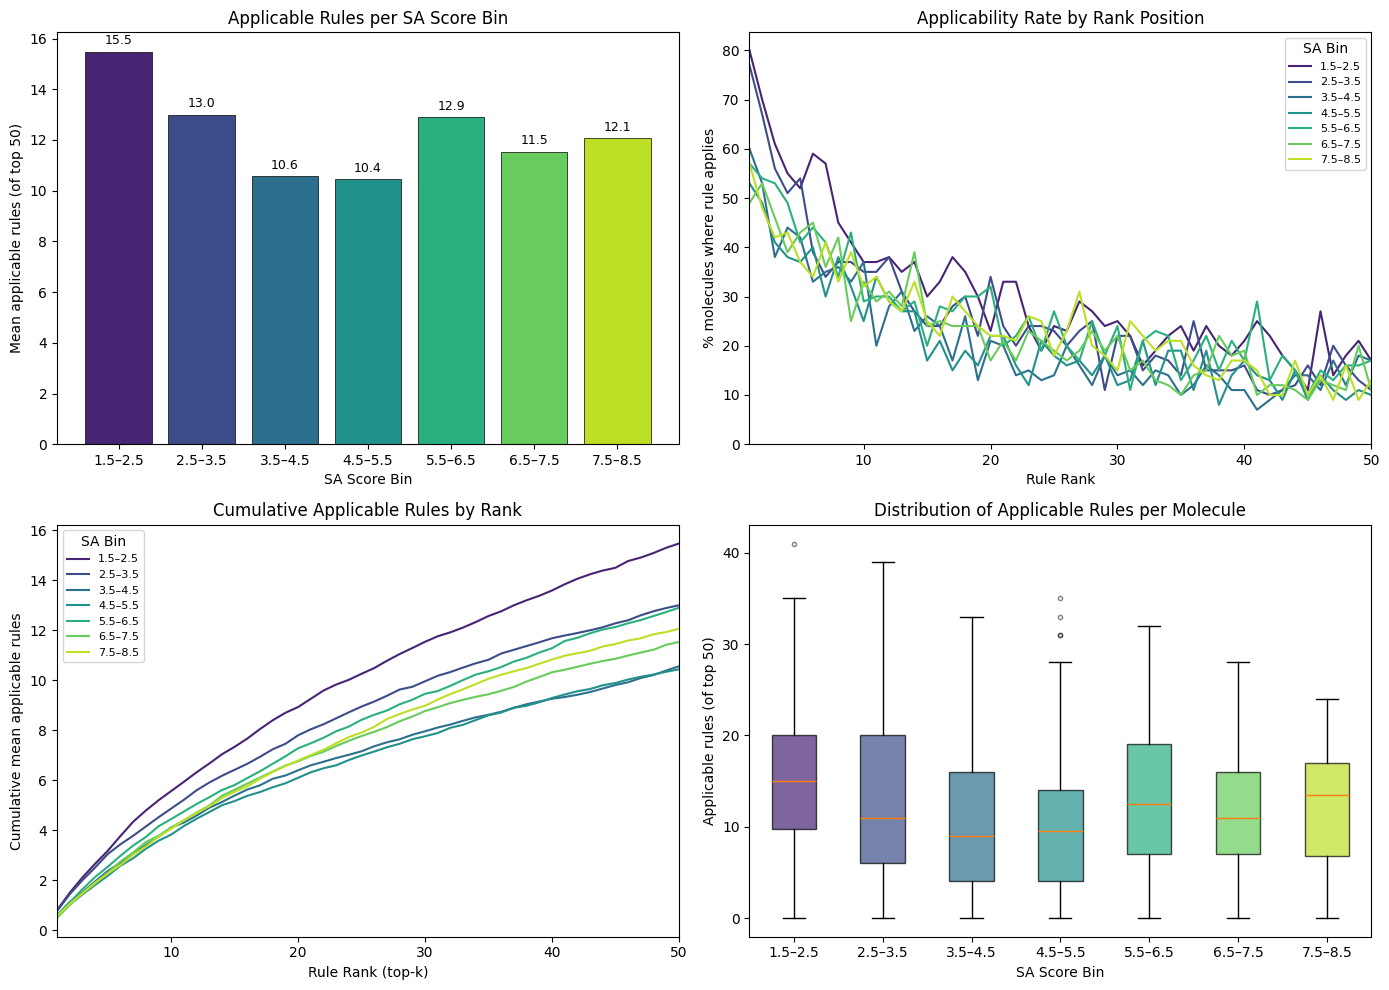

Saved: policy_topk_applicability.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

colors = plt.cm.viridis(np.linspace(0.1, 0.9, len(BINS)))

# Plot 1: Mean number of applicable rules per bin
ax = axes[0, 0]
ax.bar(bin_summary["bin_label"], bin_summary["mean_applicable"], color=colors, edgecolor="black", linewidth=0.5)
ax.set_xlabel("SA Score Bin")
ax.set_ylabel(f"Mean applicable rules (of top {TOP_RULES})")
ax.set_title("Applicable Rules per SA Score Bin")
ax.set_ylim(0, None)
for i, v in enumerate(bin_summary["mean_applicable"]):
    ax.text(i, v + 0.3, f"{v:.1f}", ha="center", fontsize=9)

# Plot 2: Applicability rate by rank, per bin
ax = axes[0, 1]
for i, bin_name in enumerate(BINS):
    sub = rank_app[rank_app["bin"] == bin_name]
    ax.plot(sub["rank"], sub["frac_applicable"] * 100, label=BIN_LABELS[i], color=colors[i], linewidth=1.5)
ax.set_xlabel("Rule Rank")
ax.set_ylabel("% molecules where rule applies")
ax.set_title("Applicability Rate by Rank Position")
ax.legend(fontsize=8, title="SA Bin", loc="upper right")
ax.set_xlim(1, TOP_RULES)
ax.set_ylim(0, None)

# Plot 3: Cumulative applicable rules by rank
ax = axes[1, 0]
for i, bin_name in enumerate(BINS):
    sub = rank_app[rank_app["bin"] == bin_name].sort_values("rank")
    cumul = sub["frac_applicable"].cumsum()
    ax.plot(sub["rank"], cumul, label=BIN_LABELS[i], color=colors[i], linewidth=1.5)
ax.set_xlabel("Rule Rank (top-k)")
ax.set_ylabel("Cumulative mean applicable rules")
ax.set_title("Cumulative Applicable Rules by Rank")
ax.legend(fontsize=8, title="SA Bin", loc="upper left")
ax.set_xlim(1, TOP_RULES)

# Plot 4: Distribution of applicable rules per molecule
ax = axes[1, 1]
box_data = [mol_summary[mol_summary["bin"] == b]["n_applicable"].values for b in BINS]
bp = ax.boxplot(box_data, labels=BIN_LABELS, patch_artist=True, showfliers=True,
                flierprops={"markersize": 3, "alpha": 0.5})
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xlabel("SA Score Bin")
ax.set_ylabel(f"Applicable rules (of top {TOP_RULES})")
ax.set_title("Distribution of Applicable Rules per Molecule")

plt.tight_layout()
plt.savefig("policy_topk_applicability.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: policy_topk_applicability.png")

## 7. Probability mass on applicable vs. non-applicable rules

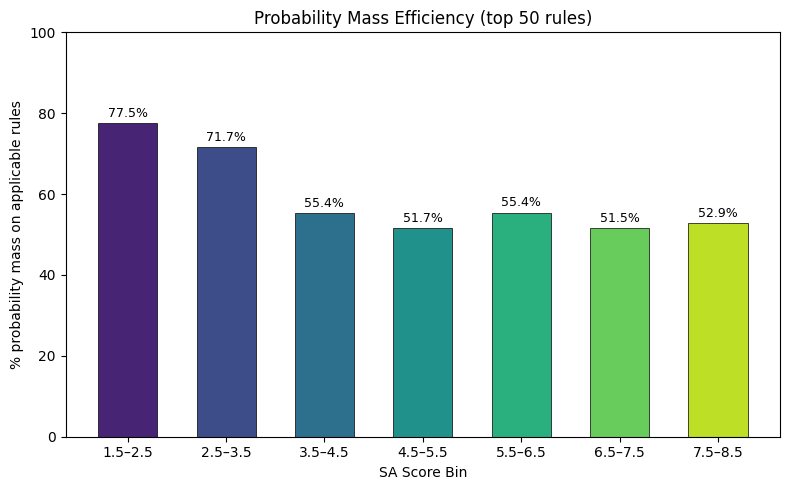

Saved: policy_topk_prob_mass.png


In [10]:
# For each bin, how much probability mass lands on applicable rules?
prob_analysis = (
    df.groupby(["bin", "applicable"])["prob"]
    .sum()
    .unstack(fill_value=0)
    .rename(columns={True: "prob_applicable", False: "prob_inapplicable"})
    .reset_index()
)
prob_analysis["total"] = prob_analysis["prob_applicable"] + prob_analysis["prob_inapplicable"]
prob_analysis["pct_applicable"] = 100 * prob_analysis["prob_applicable"] / prob_analysis["total"]

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(BINS))
w = 0.6
ax.bar(x, prob_analysis["pct_applicable"], w, color=colors, edgecolor="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(BIN_LABELS)
ax.set_xlabel("SA Score Bin")
ax.set_ylabel("% probability mass on applicable rules")
ax.set_title(f"Probability Mass Efficiency (top {TOP_RULES} rules)")
ax.set_ylim(0, 100)
for i, v in enumerate(prob_analysis["pct_applicable"]):
    ax.text(i, v + 1.5, f"{v:.1f}%", ha="center", fontsize=9)
plt.tight_layout()
plt.savefig("policy_topk_prob_mass.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: policy_topk_prob_mass.png")

## 8. Rank of first applicable rule

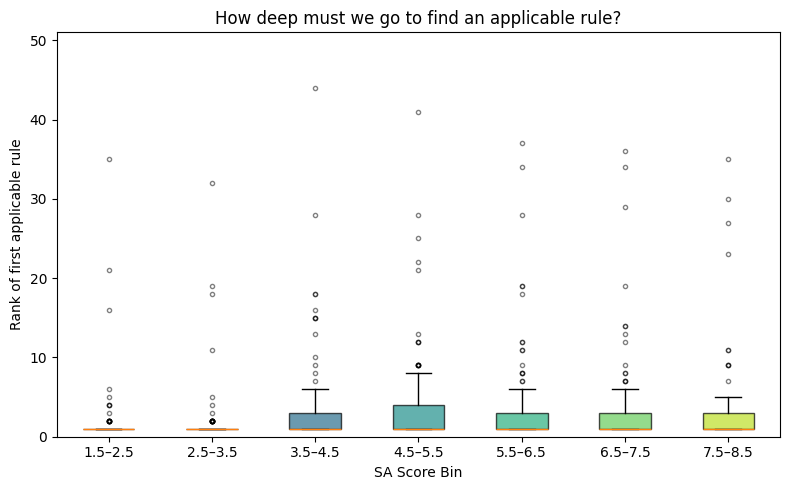

Saved: policy_topk_first_applicable.png


In [11]:
# Distribution of the rank at which the first applicable rule appears
first_rank = mol_summary[mol_summary["has_any_applicable"]].copy()

fig, ax = plt.subplots(figsize=(8, 5))
box_data = [first_rank[first_rank["bin"] == b]["first_applicable_rank"].values for b in BINS]
bp = ax.boxplot(box_data, labels=BIN_LABELS, patch_artist=True, showfliers=True,
                flierprops={"markersize": 3, "alpha": 0.5})
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
ax.set_xlabel("SA Score Bin")
ax.set_ylabel("Rank of first applicable rule")
ax.set_title("How deep must we go to find an applicable rule?")
ax.set_ylim(0, TOP_RULES + 1)
plt.tight_layout()
plt.savefig("policy_topk_first_applicable.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: policy_topk_first_applicable.png")

## 9. Save raw data

In [12]:
df.to_csv("policy_topk_raw.csv", index=False)
mol_summary.to_csv("policy_topk_mol_summary.csv", index=False)
print("Saved: policy_topk_raw.csv, policy_topk_mol_summary.csv")

# Final summary table
print("\n" + "="*80)
print(f"Top-{TOP_RULES} Ranking Policy Applicability Summary")
print("="*80)
for _, row in bin_summary.iterrows():
    print(f"  SA {row['bin_label']:>7s}:  {row['mean_applicable']:.1f} ± {row['std_applicable']:.1f} applicable  "
          f"({row['mean_frac']*100:.1f}%)  |  {row['pct_with_any']:.0f}% have ≥1 applicable rule")

Saved: policy_topk_raw.csv, policy_topk_mol_summary.csv

Top-50 Ranking Policy Applicability Summary
  SA 1.5–2.5:  15.5 ± 8.0 applicable  (30.9%)  |  99% have ≥1 applicable rule
  SA 2.5–3.5:  13.0 ± 8.6 applicable  (26.0%)  |  98% have ≥1 applicable rule
  SA 3.5–4.5:  10.6 ± 7.9 applicable  (21.1%)  |  95% have ≥1 applicable rule
  SA 4.5–5.5:  10.4 ± 8.4 applicable  (20.9%)  |  95% have ≥1 applicable rule
  SA 5.5–6.5:  12.9 ± 8.0 applicable  (25.8%)  |  98% have ≥1 applicable rule
  SA 6.5–7.5:  11.5 ± 7.0 applicable  (23.1%)  |  93% have ≥1 applicable rule
  SA 7.5–8.5:  12.1 ± 6.8 applicable  (24.1%)  |  96% have ≥1 applicable rule
